# Анализ и прогнозирование временных рядов методами искусственного интеллекта

## **Практическая работа 1. Метрики и меры схожести между временными рядами.**

Смените рабочую директорию с помощью команды `chdir()`. Для этого передайте этой команде свой путь до каталога, в котором содержатся материалы первой практической работы. После выполнения этой команды все последующие операции с файлами и каталогами будут производиться относительно указанного каталога.

In [84]:
import os

practice_dir_path = 'C:/Users/dah12/Desktop/Магистратура/3 семестр/TimeSeriesCourse/01 Basics'
os.chdir(practice_dir_path)

Выполните команды, которые автоматически перезагружают все импортированные модули при их изменении.

In [85]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Импортируйте библиотеки и модули, необходимые для реализации практической работы 1.

In [86]:
#%pip install numpy==1.26.4 scikit-learn==1.3.2 sktime==0.24.0

In [87]:
#%pip install --force-reinstall --no-cache-dir numpy==1.26.4 scipy==1.11.4 scikit-learn==1.3.2

In [88]:
import numpy
import scipy
import sklearn
import sktime

print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)
print("sklearn:", sklearn.__version__)
print("sktime:", sktime.__version__)

numpy: 1.24.4
scipy: 1.8.1
sklearn: 1.3.2
sktime: 0.24.0


In [89]:
import numpy as np
import pandas as pd
import random

import sys
print(sys.executable)


from sktime.distances import euclidean_distance, dtw_distance, pairwise_distance
from sklearn.metrics import silhouette_score
import cv2
import imutils
import glob
import matplotlib.pyplot as plt

from modules.metrics import ED_distance, norm_ED_distance, DTW_distance
from modules.pairwise_distance import PairwiseDistance
from modules.clustering import TimeSeriesHierarchicalClustering
from modules.classification import TimeSeriesKNN, calculate_accuracy
from modules.image_converter import Image2TimeSeries
from modules.utils import read_ts, z_normalize, sliding_window, random_walk
from modules.plots import plot_ts



C:\Users\dah12\AppData\Local\Programs\Python\Python310\python.exe


## **Часть 1.** Функции расстояния: евклидова метрика и DTW мера. Матрица расстояний. Иерархическая кластеризация временных рядов.

### **Задача 1.**
Реализуйте самостоятельно функцию `ED_distance()` в модуле *metrics.py*, которая вычисляет евклидово расстояние между двумя временными рядами, имеющими одинаковую длину. В качестве входных данных передайте в функцию два синтетических временных ряда некоторой заданной вами длины. Для их генерации используйте функцию `random_walk()` из модуля *utils.py*,  реализующую модель случайных блужданий (Random Walk), или стандартный модуль *random*.

**Евклидово расстояние** между двумя временными рядами $T_1$ и $T_2$ длины $n$ вычисляется следующим образом:

\begin{equation}
    \text{ED}(T_1, T_2) = \sqrt{\sum_{i=1}^{n} ({t_{1}}_i-{t_{2}}_i)^2}.
\end{equation}

Проверьте реализацию функции, сравнив свои результаты с результатами функции [`euclidean_distance()`](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.distances.euclidean_distance.html) из библиотеки *sktime*, с помощью `test_distances()`.

In [90]:
def test_distances(dist1: float, dist2: float) -> None:
    """
    Check whether your distance function is implemented correctly

    Parameters
    ----------
    dist1 : distance between two time series calculated by sktime
    dist2 : distance between two time series calculated by your function
    """

    print(f"Расстояние sktime: {dist1:.10f}")
    print(f"Расстояние полученное самим: {dist2:.10f}")


In [91]:
np.random.seed(42)

d1 = random_walk(100)
d2 = random_walk(100)

my_d = ED_distance(d1, d2)
sktime_d = euclidean_distance(d1, d2)

test_distances(sktime_d, my_d)

Расстояние sktime: 35.7211421990
Расстояние полученное самим: 35.7211421990


### **Задача 2.**

Реализуйте самостоятельно функцию `DTW_distance()` в модуле *metrics.py*, которая вычисляет DTW расстояние между двумя временными рядами, имеющими одинаковую длину. Для вычисления расстояния между элементами временных рядов в DTW мере используйте евклидово расстояние. Временные ряды сгенерируйте аналогичным образом, как в задаче 1, или используйте уже созданные.

**Динамическая трансформация временной шкалы (Dynamic Time Warping, DTW)** – мера схожести между двумя временными рядами $T_1$ и $T_2$ длины $n$, вычисляемая следующим образом:

\begin{equation}
\text{DTW}(T_1, T_2) = d(n,n),
\\ d(i,j) = ({t_{1}}_i - {t_{2}}_j)^2 + \min \left\{
	\begin{array}{l l}
	d(i-1,j), \\
	d(i,j-1), \\
	d(i-1,j-1),
	\end{array}
	\right.
\\ d(0,0)=0, \quad d(i,0)=d(0,j)=\infty, \quad  1 \leqslant i,j \leqslant n.
\end{equation}

Сравните свои результаты с результатами функции [`dtw_distance()`](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.distances.dtw_distance.html) из библиотеки *sktime*. Для этого используйте `test_distances()` из задачи 1.

In [92]:
d1 = random_walk(100)
d2 = random_walk(100)

my_d = DTW_distance(d1, d2)
sktime_d = dtw_distance(d1, d2)

test_distances(sktime_d, my_d)

Расстояние sktime: 4490.0000000000
Расстояние полученное самим: 4490.0000000000


### **Задача 3.**
Реализуйте нахождение матрицы расстояний между несколькими временными рядами.
Для этого заполните все методы c недостающим кодом в классе `PairwiseDistance` из модуля *pairwise_distance.py*. Для вычисления расстояний между рядами используйте ранее реализованные вами функции `ED_distance()` и `DTW_distance()` из модуля *metrics.py*.

Матрица расстояний между временными рядами определяется следующим образом. Пусть дано множество $S$, состоящее из $K$ временных рядов длины $n$: $\;S = \{T_1, T_2, ..., T_K\}, \; T_i \in \mathbb{R}^n$. Тогда под **матрицей расстояний** $D \in \mathbb{R}^{K \times K}$ понимается квадратная матрица, где каждый ее элемент $d(i,j)$ представляет собой расстояние между временными рядами $T_i$ и $T_j$ из множества $S$:
\begin{equation}
d(i,j) = dist(T_i, T_j), \quad T_i, T_j \in S, \quad 1 \leqslant i,j \leqslant K.
\end{equation}

Поскольку евклидова метрика и DTW мера удовлетворяют аксиоме симметричности (т.е. $dist(T_i, T_j)=dist(T_j, T_i)$), то матрица расстояний $D$ будет симметричной относительно главной диагонали. Для ускорения вычислений достаточно найти ее верхний треугольник, а нижний треугольник матрицы заполнить значениями верхнего треугольника следующим образом:
\begin{equation}
d(j,i) = d(i,j), \; где \; i < j.
\end{equation}

<center><img src="https://github.com/mzym/TimeSeriesCourse/blob/main/practice/01%20Basics/img/distance_matrix.png?raw=true" width="600"></center>

Сгенерируйте множество, состоящее из $K$ временных рядов некоторой длины $n$. Вычислите матрицы евклидовых и DTW расстояний между ними. Проверьте реализованные вами методы, сравнив свои результаты с результатами функции [`pairwise_distance()`](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.distances.pairwise_distance.html) из библиотеки *sktime*.

In [93]:
def test_matrices(matrix1 : np.ndarray, matrix2 : np.ndarray) -> None:
    """
    Check whether your matrix function is implemented correctly

    Parameters
    ----------
    matrix1 : distance matrix calculated by sktime
    matrix2 : distance matrix calculated by your function
    """

    print(f"\nРазмер матрицы собственной:         {matrix1.shape}")
    print(f"Размер матрицы sktime: {matrix1.shape}")
    
    print("\nПервые 5x5 элементов матрицы собственной:")
    print(matrix1[:5, :5].round(5))
    print("\nПервые 5x5 элементов из sktime:")
    print(matrix2[:5, :5].round(5))

    

In [94]:
data = np.random.randn(5, 20)

# Евклидовое расстояние
pwd = PairwiseDistance(metric='euclidean', is_normalize=False)

my_m = pwd.calculate(data)
sktime_m = pairwise_distance(data, metric='euclidean')



test_matrices(sktime_m, my_m)

# dtw
pwd = PairwiseDistance(metric='dtw', is_normalize=False)

my_m = pwd.calculate(data)
sktime_m = pairwise_distance(data, metric='dtw')

test_matrices(sktime_m, my_m)


Размер матрицы собственной:         (5, 5)
Размер матрицы sktime: (5, 5)

Первые 5x5 элементов матрицы собственной:
[[0.      6.40706 6.43424 6.51425 4.35389]
 [6.40706 0.      5.33764 6.68594 4.69838]
 [6.43424 5.33764 0.      6.5123  5.11041]
 [6.51425 6.68594 6.5123  0.      5.93199]
 [4.35389 4.69838 5.11041 5.93199 0.     ]]

Первые 5x5 элементов из sktime:
[[0.      6.40706 6.43424 6.51425 4.35389]
 [6.40706 0.      5.33764 6.68594 4.69838]
 [6.43424 5.33764 0.      6.5123  5.11041]
 [6.51425 6.68594 6.5123  0.      5.93199]
 [4.35389 4.69838 5.11041 5.93199 0.     ]]

Размер матрицы собственной:         (5, 5)
Размер матрицы sktime: (5, 5)

Первые 5x5 элементов матрицы собственной:
[[ 0.      12.26558 15.3812  12.31341  5.80936]
 [12.26558  0.       8.67417 17.45808  9.84676]
 [15.3812   8.67417  0.      20.05127  8.10722]
 [12.31341 17.45808 20.05127  0.      12.57046]
 [ 5.80936  9.84676  8.10722 12.57046  0.     ]]

Первые 5x5 элементов из sktime:
[[ 0.      12.26558 15.3812

### **Задача 4.**
Далее рассмотрим задачу иерархической кластеризации временных рядов, где будет использоваться предвычисленная матрица расстояний.

Для этого сначала загрузите набор временных рядов CBF из файла *CBF_TRAIN.txt*, который располагается в директории *./datasets/part1*. Каждая строка данного файла содержит целевую переменную (класс: 0, 1 или 2) в первом столбце и временной ряд в остальных столбцах. Набор CBF является синтетическим и включает в себя 30 временных рядов,  каждый из которых принадлежит к одному из трех классов.

In [95]:
url = './datasets/part1/CBF_TRAIN.txt'

data = read_ts(url)

ts_set = data[:, 1:]
labels = data[:, 0]
print(ts_set)
print(labels)

[[-0.46427649 -0.55504787 -0.8428431  ... -0.63870583 -0.96366425
  -1.2451691 ]
 [-0.89697208 -0.68568553 -1.3513818  ... -0.58209806 -1.2590094
  -1.3925241 ]
 [-0.46469596 -0.56773891 -0.03202276 ... -0.2844857  -0.68788913
  -0.88760835]
 ...
 [-0.18049272 -0.98893115 -0.30170209 ...  0.01975953 -0.94213238
   0.01312074]
 [-0.26588817  0.01312794 -1.0288614  ... -0.40554432 -0.93063204
  -0.77730274]
 [-0.99331525 -0.86941944 -0.34513531 ... -1.1708605  -1.3251094
  -0.89458237]]
[1. 1. 1. 3. 2. 2. 1. 3. 2. 1. 2. 2. 1. 2. 2. 3. 2. 2. 1. 3. 2. 2. 1. 1.
 3. 3. 2. 3. 3. 1.]


Выполните визуализацию по одному временному ряду из каждого класса. Для этого используйте функцию `plot_ts()` из модуля *plots.py*.

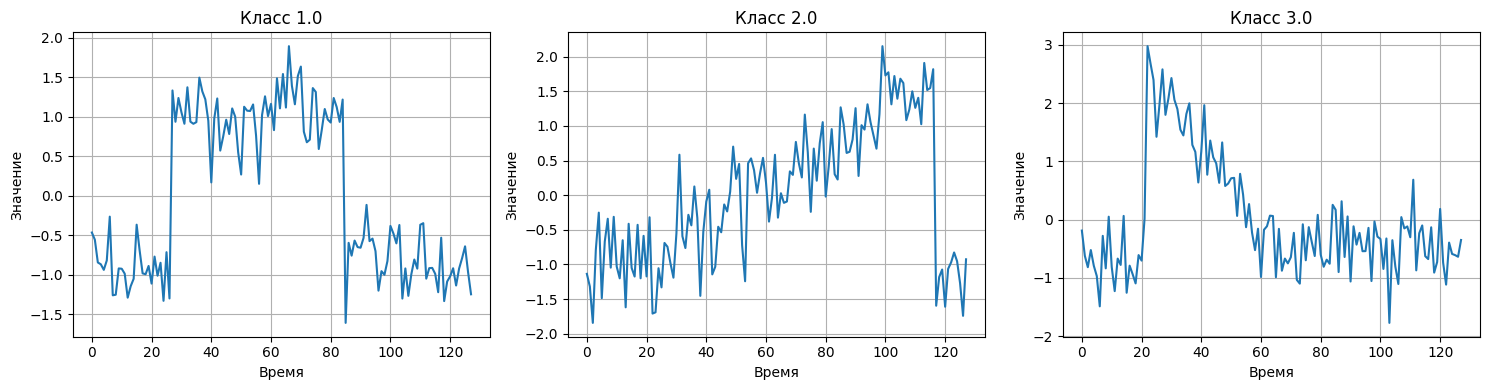

In [96]:
plt.figure(figsize=(15, 4))
unique_labels = np.unique(labels)

for i, class_id in enumerate(unique_labels):
    idx = np.where(labels == class_id)[0][0]
    
    plt.subplot(1, len(unique_labels), i + 1)
    plt.plot(ts_set[idx])
    plt.title(f'Класс {class_id}')
    plt.xlabel('Время')
    plt.ylabel('Значение')
    plt.grid(True)

plt.tight_layout()
plt.show()

Далее самостоятельно реализуйте класс `TimeSeriesHierarchicalClustering` из модуля *clustering.py*, который выполняет иерархическую кластеризацию временных рядов.

Перед тем как приступить к реализации, изучите скелет этого класса. Реализуйте метод `fit()`, выполняющий кластеризацию данных на основе предвычисленной матрицы расстояний, которая передается в данный метод. Поскольку реализовать иерархическую кластеризацию довольно сложно, используйте готовую реализацию [`AgglomerativeClustering`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html) из *sklearn*.   

Выполните иерархическую кластеризацию загруженных временных рядов CBF для двух функций расстояния: евлидовой метрики и DTW меры.
Для этого сначала найдите матрицы расстояний между временными рядами, используя класс `PairwiseDistance`, и передайте каждую матрицу в метод `fit()` для кластеризации.
Далее выполните визуализацию результатов в виде дендрограмм с помощью метода `plot_dendrogram()`, передав исходный набор временных рядов и их метки.

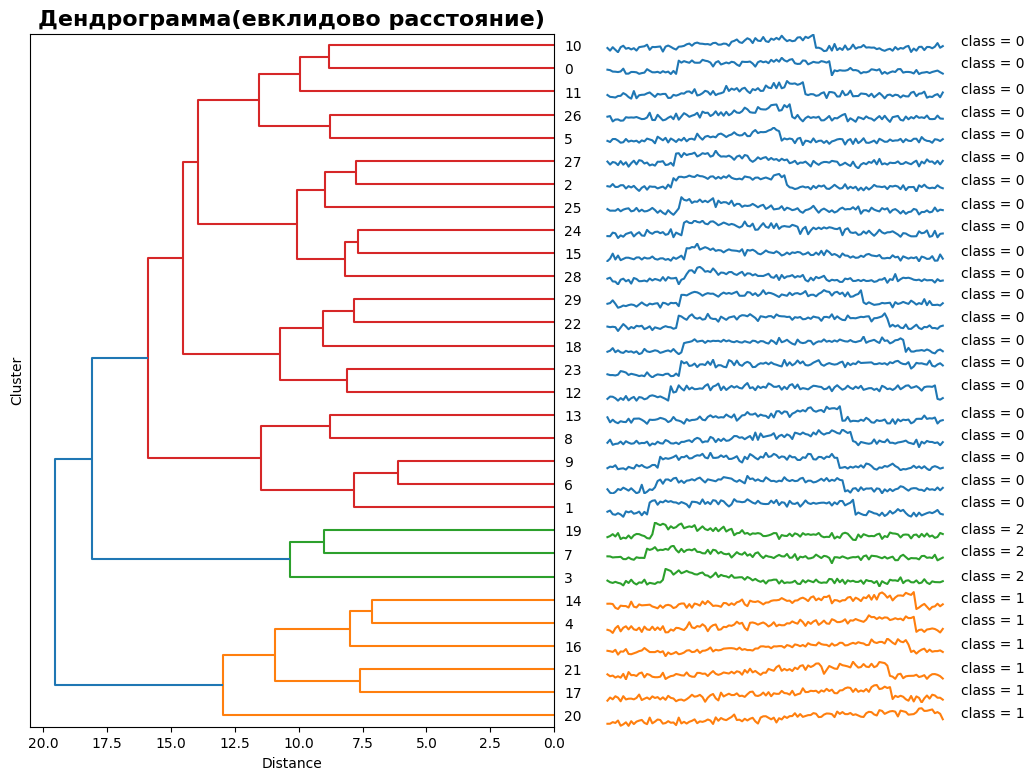

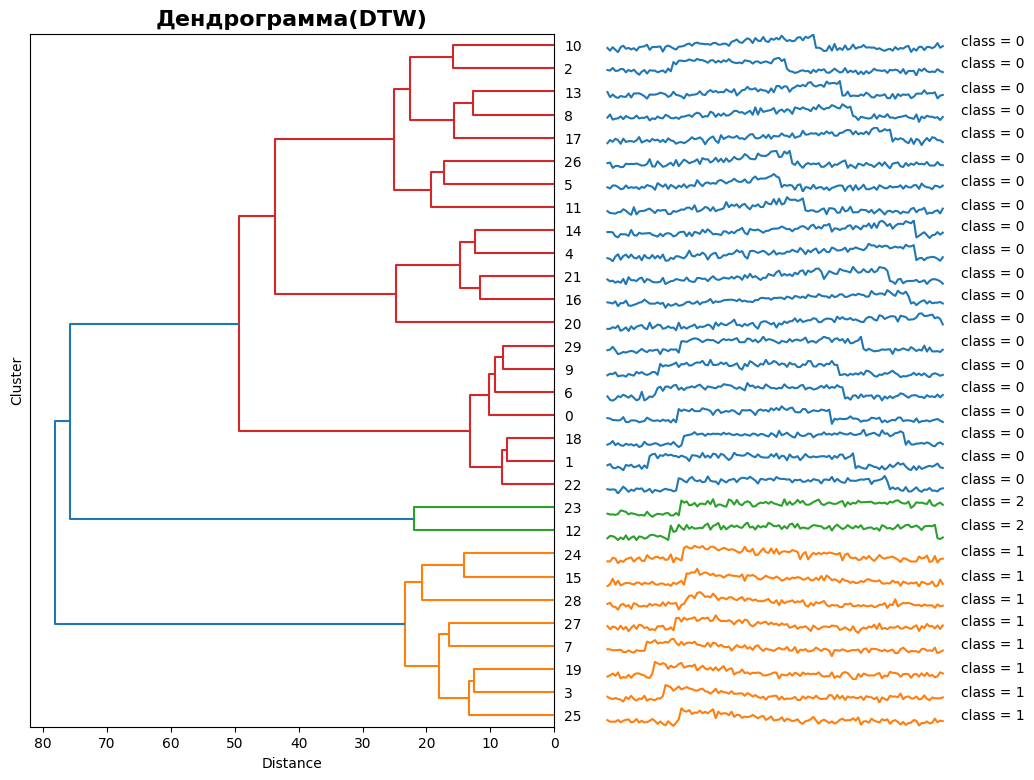

In [97]:
pwd_euclidean = PairwiseDistance(metric='euclidean', is_normalize=False)
euclidean_matrix = pwd_euclidean.calculate(ts_set)

clustering_euclidean = TimeSeriesHierarchicalClustering(n_clusters=3, method='complete')
clustering_euclidean.fit(euclidean_matrix)

predicted_labels_euclidean = clustering_euclidean.labels_

pwd_dtw = PairwiseDistance(metric='dtw', is_normalize=False)
dtw_matrix = pwd_dtw.calculate(ts_set)

clustering_dtw = TimeSeriesHierarchicalClustering(n_clusters=3, method='complete')
clustering_dtw.fit(dtw_matrix)
predicted_labels_dtw = clustering_dtw.labels_

df_euclidean = pd.DataFrame(ts_set.T)
clustering_euclidean.plot_dendrogram(
    df=df_euclidean,
    labels=predicted_labels_euclidean,
    ts_hspace=12,
    title='Дендрограмма(евклидово расстояние)'
)
plt.show()

df_dtw = pd.DataFrame(ts_set.T)
clustering_dtw.plot_dendrogram(
    df=df_dtw,
    labels=predicted_labels_dtw,
    ts_hspace=12,
    title='Дендрограмма(DTW)'
)
plt.show()

Сравните результаты иерархической кластеризации, полученные при двух различных функций расстояния, с помощью силуэтного коэффициента. Для этого используйте функцию [`silhouette_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html) из библиотеки *sklearn*, передав в нее предвычисленную матрицу расстояний и предсказанные метки.

**Силуэтный коэффициент** – метрика, которая оценивает качество кластеризации на основе исходной выборки и результатов кластеризации без необходимости знания об истинных метках объектов.

Силуэтный коэффициент для выборки показывает, насколько среднее расстояние до объектов своего кластера отличается от среднего расстояния до объектов других кластеров. Пусть дана выборка $X$, состоящая из $N$ объектов. Предположим, что объекты этой выборки были разбиты на кластеры $c_1, ... c_K$, $c_i \in C$, с помощью некоторого алгоритма кластеризации. Тогда силуэтный коэффициент для выборки будет вычисляться следующим образом:

\begin{equation}
sil\_coef = \frac{1}{N} \sum_{c_k \in C} \sum_{x_i \in c_k} \frac{b(x_i, c_k) - a(x_i, c_k)}{\max(a(x_i, c_k), b(x_i, c_k))},
\end{equation}

где $a(x_i, c_k)$ – среднее расстояние от объекта $x_i \in c_k$ до других объектов из этого же кластера $c_k$; <br> $b(x_i, c_k)$  – среднее расстояние от объекта $x_i \in c_k$ до объектов из другого кластера $c_l$, $k \neq l$.

Силуэтный коэффициент принимает значения от  −1  до  1:
*   –1 означает, что кластеры плохие, размытые;
*   0 означает, что кластеры накладываются друг на друга;
*   1 означает, что кластеры плотные и хорошо отделены друг от друга.

Таким образом, чем ближе значение коэффициента к 1, тем лучше кластеризованы данные.

In [98]:
s_euclidean = silhouette_score(
    euclidean_matrix,
    predicted_labels_euclidean,
    metric='precomputed'
)

s_dtw = silhouette_score(
    dtw_matrix,
    predicted_labels_dtw,
    metric='precomputed'
)

print(f"Силуэтный коэффициент (Евклидово расстояние): {s_euclidean}")
print(f"Силуэтный коэффициент (DTW):                  {s_dtw}")

Силуэтный коэффициент (Евклидово расстояние): 0.1803917727906887
Силуэтный коэффициент (DTW):                  0.3881450644470224


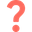
Проанализируйте полученные результаты кластеризации с помощью построенных дендрограмм и вычисленных силуэтных коэффициентов. Какая, на ваш взгляд, функция расстояния показала лучший результат и почему? Укажите, в каких случаях более предпочтительно использовать DTW меру, чем евклидову метрику.

У евклидового расстояния значение получилось близким к нулю. Это говорит о том, что кластеры находятся близко друг к другу и поэтому разделены не очень хорошо.
У DTW значение получилось примерно 0.5. В этом случае кластеры выглядят более плотными и лучше отделены друг от друга.

DTW показал результат более чем в два раза лучше, чем евклидово расстояние. Это можно объяснить особенностями набора данных CDF (Cylinder-Bell-Funnel), который является синтетическим и содержит временные ряды с определёнными паттернами. Такие ряды могут иметь различные сдвиги и задержки по времени.

В отличие от евклидова расстояния, которое сравнивает значения временных рядов в одинаковых позициях, DTW позволяет учитывать временные сдвиги и находить наиболее подходящее соответствие между точками двух рядов. Поэтому для данного набора данных DTW оказался более подходящим методом сравнения временных рядов.

## **Часть 2.** $Z$-нормализация временных рядов.

### **Задача 5.**
Реализуйте функцию вычисления нормализованного евклидова расстояния между временными рядами `norm_ED_distance()` в модуле *metrics.py* и проверьте правильность своей реализации, сравнив полученные результаты с результатами функции [`ed_distance()`](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.distances.euclidean_distance.html) из библиотеки *sktime*, в которую необходимо передать <u>нормализованные</u> временные ряды. Для нормализации временных рядов используйте функцию `z-normalize()` из *utils.py*.  Для проверки можно использовать синтетические временные ряды из первой части или заново их сгенерировать.

**Нормализованная евклидова метрика** между двумя временными рядами $T_1$ и $T_2$ длины $n$ вычисляется следующим образом:

\begin{equation}
	\text{ED}_{norm}(T_1, T_2) = \sqrt {\Big|\; 2n\left(1-\dfrac{<T_1, T_2> - \; n \; \cdotp \mu_{T_1} \; \cdotp \mu_{T_2}}{n \; \cdotp \sigma_{T_1} \; \cdotp \sigma_{T_2}}\right)\Big|},
\end{equation}

где $<T_1, T_2>$ – скалярное произведение временных рядов, $\mu_{T_1}$ и $\mu_{T_2}$, $\sigma_{T_1}$ и $\sigma_{T_2}$ – среднее арифметическое и стандартное отклонение временных рядов соответственно.

**Среднее арифметическое** $\mu_T$ и **стандартное отклонение** $\sigma_T$ временного ряда $T$ длины $n$ вычисляются по следующим формулам:

\begin{equation}
	\mu_{T} = \frac{1}{n}\sum\limits_{i=1}^{n} t_{i}, \\[1em]
	\sigma_{T} = \sqrt{\frac{1}{n}\sum\limits_{i=1}^{n} t_i^2-\mu_{T}^2}.
\end{equation}

In [99]:
url = './datasets/part1/CBF_TRAIN.txt'
data = read_ts(url)
ts_set = data[:, 1:]

d1 = ts_set[0]
d2 = ts_set[1]

# Вычисляем расстояние с помощью реализованной функции
my_d = norm_ED_distance(d1, d2)

# Вычисляем расстояние через sktime с z-нормализацией
d1_norm = z_normalize(d1)
d2_norm = z_normalize(d2)
sktime_d = euclidean_distance(d1_norm, d2_norm)

test_distances(sktime_d, my_d)

Расстояние sktime: 9.4864937813
Расстояние полученное самим: 9.4864937813


### **Задача 6.**
Далее убедимся, что выполнение $z$-нормализации на этапе предобработки данных имеет важное значение и может повысить точность решаемой задачи.

В данном задании вы продолжите решать задачу иерархической кластеризации. В качестве данных будут использоваться два временных ряда из набора данных [BIDMC](https://physionet.org/content/chfdb/1.0.0/). Набор BIDMC состоит из записей ЭКГ-сигналов, снятых с 15 пациентов с сердечной недостаточностью тяжелой степени.  

Загрузите два временных ряда и визуализируйте их с помощью функции `plot_ts()` из модуля *plots.py*.

In [100]:
url1 = './datasets/part2/chf10.csv'
d1 = read_ts(url1)

url2 = './datasets/part2/chf11.csv'
d2 = read_ts(url2)

In [101]:
d_set = np.concatenate((d1, d2), axis=1).T

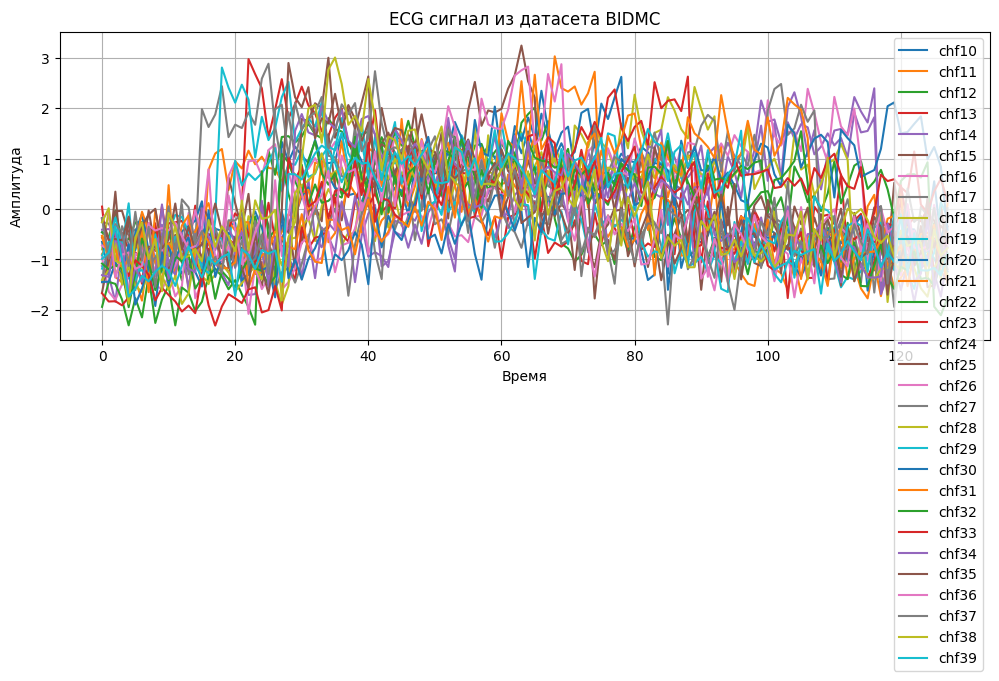

In [102]:
plt.figure(figsize=(12, 4))
for i in range(ts_set.shape[0]):
    plt.plot(ts_set[i], label=f'chf{10+i}')
plt.xlabel('Время')
plt.ylabel('Амплитуда')
plt.title('ECG сигнал из датасета BIDMC')
plt.legend()
plt.grid(True)
plt.show()

Разделите каждый временной ряд на непересекающиеся подпоследовательности с помощью техники скользящего окна. Для этого используйте функцию `sliding_window()` из модуля *utils.py*, передав в нее временной ряд, заданную длину подпоследовательности и величину шага. В нашем случае, величина шага равна длине подпоследовательности.

In [103]:
m = 125
subs_set1 = sliding_window(d_set[0], m, m-1)
subs_set2 = sliding_window(d_set[1], m, m-1)

Сформируйте множество всех подпоследовательностей, извлеченных из двух временных рядов, и массив меток подпоследовательностей в соответствии с их принадлежностью к временному ряду.

In [104]:
subs_set = np.concatenate((subs_set1[0:15], subs_set2[0:15]))
labels = np.array([0]*subs_set1[0:15].shape[0] + [1]*subs_set2[0:15].shape[0])

Добавьте в класс `PairwiseDistance` из модуля *pairwise_distance.py* возможность вычисления нормализованной евклидовой метрики между временными рядами. Если матрица расстояний строится для нормализованных временных рядов на основе евклидовой метрики, то должна вызываться функция `norm_ED_distance()`. Для остальных метрик/мер схожести перед нахождением матрицы расстояний временные ряды должны подтвергаться $z$-нормализации с помощью функции `z_normalize()` из модуля *utils.py*.

Далее выполните иерархическую кластеризацию подпоследовательностей двух временных рядов с использованием предварительно построенных матриц расстояний на основе классической и нормализованной евклидовой метрики.

In [105]:
# Без нормализации
pwd_euclidean = PairwiseDistance(metric='euclidean', is_normalize=False)
euclidean_matrix = pwd_euclidean.calculate(subs_set)

clustering_euclidean = TimeSeriesHierarchicalClustering(n_clusters=2, method='complete')
clustering_euclidean.fit(euclidean_matrix)
pred_labels_no_norm = clustering_euclidean.labels_

# С нормализацией
pwd_norm_euclidean = PairwiseDistance(metric='euclidean', is_normalize=True)
norm_matrix = pwd_norm_euclidean.calculate(subs_set)

clustering_norm = TimeSeriesHierarchicalClustering(n_clusters=2, method='complete')
clustering_norm.fit(norm_matrix)
pred_labels_norm = clustering_norm.labels_

# Оценка качества
sil_no_norm = silhouette_score(euclidean_matrix, pred_labels_no_norm, metric='precomputed')
sil_norm = silhouette_score(norm_matrix, pred_labels_norm, metric='precomputed')

print(f"Силуэтный коэффициент (без нормализации): {sil_no_norm}")
print(f"Силуэтный коэффициент (с нормализацией):  {sil_norm}")

Силуэтный коэффициент (без нормализации): 0.41829092209953717
Силуэтный коэффициент (с нормализацией):  0.32752186865268157


Вычислите силуэтные коэффициенты для оценки качества кластеризации с нормализацией и без нее, как это было сделано в задаче 4 части 1.

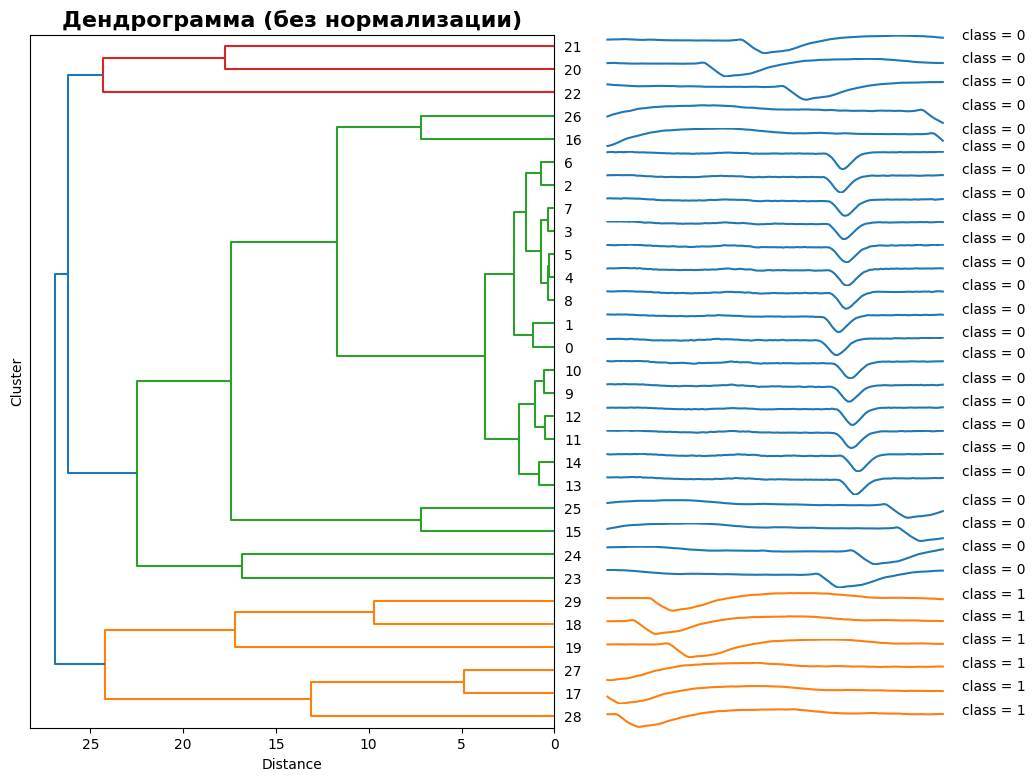

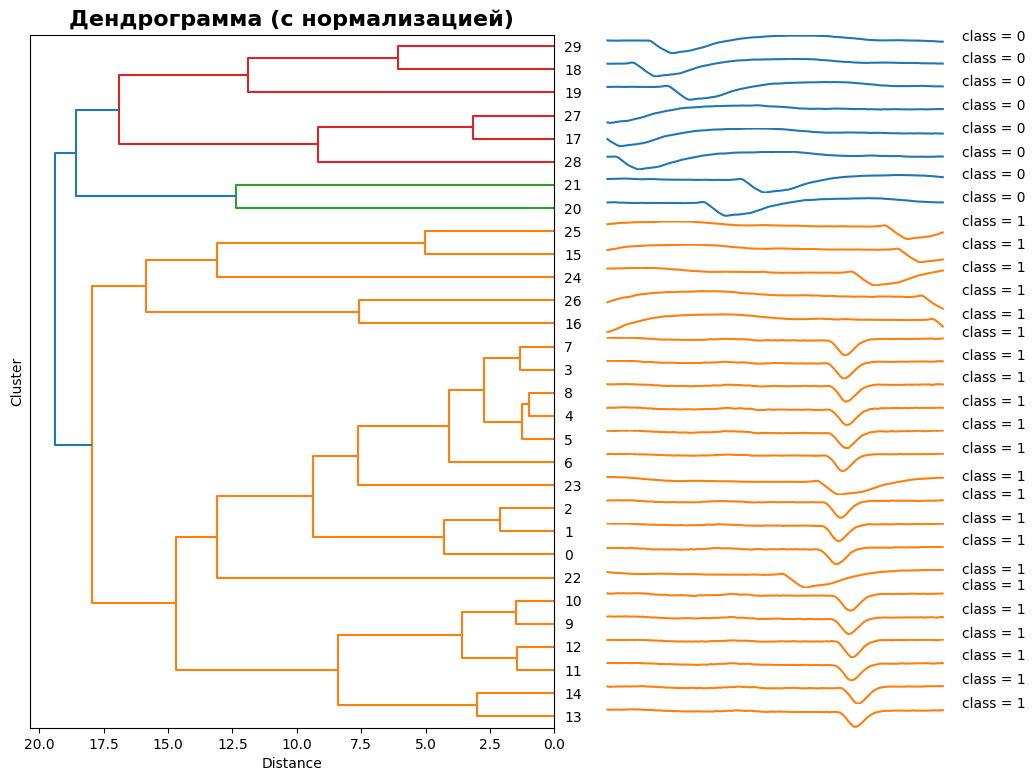

In [106]:
# Визуализация дендрограмм
df_no_norm = pd.DataFrame(subs_set.T)
clustering_euclidean.plot_dendrogram(
    df=df_no_norm,
    labels=pred_labels_no_norm,
    ts_hspace=12,
    title='Дендрограмма (без нормализации)'
)
plt.show()

df_norm = pd.DataFrame(subs_set.T)
clustering_norm.plot_dendrogram(
    df=df_norm,
    labels=pred_labels_norm,
    ts_hspace=12,
    title='Дендрограмма (с нормализацией)'
)
plt.show()

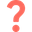
Сравните полученные результаты кластеризации с помощью построенных дендрограмм и вычисленных силуэтных коэффициентов. Позволила ли $z$-нормализации временных рядов повысить качество кластеризации?

После нормализации качество кластеризации немного ухудшилось, так как значение силуэтного коэффициента стало ниже.
Вероятно, это связано с тем, что временные ряды имеют разные масштабы, и нормализация привела их к примерно одному диапазону. Из-за этого некоторые различия между исходными сигналами сталименее заметными, что отрицательно повлияло на разделение кластеров.
В данном случае кластеризация без нормализации показала лучший результат. Нормализация была бы более полезна

## **Часть 3.** Классификация изображений, представленных в виде временных рядов.

### **Задача 7.**
В данном задании вам предстоит выполнить преобразование изображения, на котором находится некоторый объект, во временной ряд. Для этого вы реализуете один из существующих методов, предложенный в [статье Кеога и др](https://dl.acm.org/doi/10.5555/1182635.1164203).

Данный метод заключается в том, что сначала на изображении выполняется поиск контура $E = \{e_i\}_{i=1}^L$, где $e_i$ – точки контура, и центра масс объекта $O$. Затем берутся точки, расположенные на контуре объекта, следующим образом.

Рассмотрим луч $OP$ с началом в центре масс объекта $O$, направление которого совпадает с положительным направлением оси Ox (см. рисунок). Далее выполняется поворот против часовой стрелки луча $OP$ вокруг центра масс $O$ на некоторый заданный угол $α$, $1° \leqslant α \leqslant 360°$. Поворот луча будет осуществляться до тех пор, пока луч не пройдет полный оборот. Все точки $P = \{P_i\}_{i=1}^K$, $P_i \in E$, $K = \lfloor \frac{360°}{α} \rfloor$, образованные пересечением луча $OP$ с контуром $E$ во время поворота, будут являться искомыми.

На завершающем шаге метода вычисляются расстояния между центром масс объекта $O$ и найденными точками на контуре $P$. В качестве функции расстояния может быть использовано манхэттенское или евклидово расстояние. Полученные расстояния будут формировать временной ряд $T$ длины $K$:
\begin{equation}
T = \{t_i\}_{i=1}^K,\;где \; t_i = dist(O, P_i), \; P_i \in P.
\end{equation}


<center><img src="https://github.com/mzym/TimeSeriesCourse/blob/main/practice/01%20Basics/img/image2ts.png?raw=true" width="1000"></center>

Поскольку часть 3 предполагает работу с изображениями, то вы будете использовать для реализации некоторых частей кода библиотеку компьютерного зрения *cv2*. Для поиска всех необходимых функций рекомендуем воспользоваться [документацией библиотеки cv2](https://docs.opencv.org/4.x/d6/d00/tutorial_py_root.html).

Загрузите изображение *example.tif* из директории *./datasets/part3* и выполните его визуализацию с помощью соответствующих функций из библиотеки *cv2*.

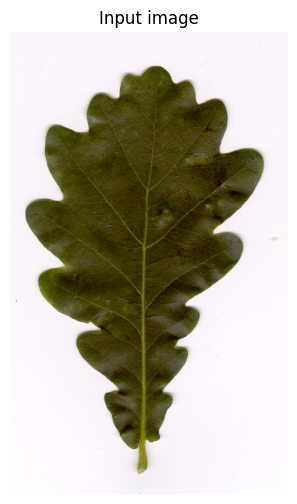

In [107]:
img = cv2.imread('./datasets/part3/example.tif')

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Input image')
plt.show()

За конвертацию изображения во временной ряд с помощью описанного выше метода отвечает функция `image2ts()` из модуля *image_converter.py*. Прежде чем исходное изображение будет преобразовано во временной ряд, сначала оно должно пройти этап предварительной обработки. Предварительная обработка включает в себя следующие шаги:

<center><img src="https://github.com/mzym/TimeSeriesCourse/blob/main/practice/01%20Basics/img/image_preprocessing.png?raw=true" width="1000"></center>

Предобработка изображения в `image2ts()` осуществляется с помощью функции `_img_preprocess()`. Реализуйте в данной функции все представленные на диаграмме шаги предварительной обработки средствами библиотеки *cv2*. Промежуточные результаты должны совпадать с представленными на диаграмме.

Далее выполните конвертацию изображения во временной ряд, передав в функцию `image2ts()` следующие заданные вами аргументы:
*   исходное загруженное изображение;
*   шаг угла поворота;
*   параметр, определяющий нужно или нет визуализировать изображение с выделенными на нем контуром, центром масс и лучами, проведенными из центра.

Визуализируйте полученный временной ряд.


In [108]:
%pip install --upgrade nbformat

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: nbformat in c:\users\dah12\appdata\local\programs\python\python310\lib\site-packages (5.11.1)




[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [109]:
import nbformat
print(nbformat.__version__)

5.11.1


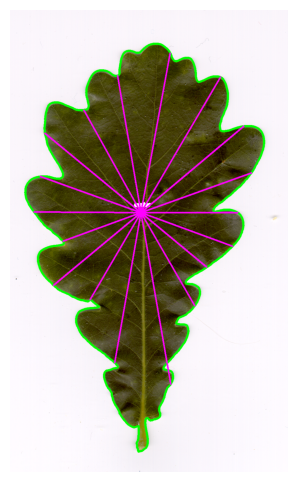

In [110]:
angle_step = 20
visualize = True

ts = Image2TimeSeries(angle_step).convert(img, visualize)
plot_ts(np.array([ts]), "Time series representation of image")

### **Задача 8.**

Выполните классификацию изображений, представленных в виде временных рядов, с помощью метода $k$ ближайших соседей (kNN).

**Метод $k$ ближайших соседей (kNN)** – алгоритм классификации, заключающийся в вычислении сходства между объектами на основе некоторой заданной метрики/меры схожести. Классифицируемый объект относится к тому классу, к которому принадлежит большинство из его $k$ соседей ($k$ ближайших к нему объектов из обучающей выборки).

Для классификации на основе алгоритма kNN необходимо выполнить следующие шаги:

1. Загрузить обучающую и тестовую выборки.

2. Задать параметр алгоритма $k$, где $k$ – количество ближайших соседей, $k \in \mathbb N^*$.

3. Для каждого объекта из тестовой выборки выполнить следующее:

    3.1. Вычислить расстояние до всех объектов из обучающей выборки на основе заданной метрики/меры схожести.
    
    3.2. Отсортировать в порядке возрастания найденные расстояния.

    3.3. Найти $k$ ближайших соседей, взяв первые $k$ минимальные расстояния из отсортированного массива расстояний.

    3.4. Назначить объекту из тестовой выборки наиболее часто встречающийся класс найденных ранее ближайших соседей.


Для этого задания вам предлагается набор данных, который содержит изображения листьев четырех различных пород деревьев: дуб, ольха, ива и липа. Набор данных состоит из обучающей и тестовой выборок, включающих по 15 и 10 изображений листьев на класс соответственно. Для составления этого набора данных изображения были взяты из [Swedish Leaf Dataset](https://www.cvl.isy.liu.se/en/research/datasets/swedish-leaf/).

Загрузите изображения из обучающей и тестовой выборок, а также их метки, используя `read_images()` и `read_ts()` соответственно.
Выполните визуализацию прецедентов выборки с помощью функции `plot_images()`.


In [111]:
def read_images(dir: str) -> list[np.ndarray]:
    """
    Load all images from a directory

    Parameters
    ----------
    dir: directory path

    Returns
    -------
    images: images from a directory
    """

    images = []
    for img_path in sorted(glob.glob(dir)):
        cv_img = cv2.imread(img_path)
        images.append(cv_img)

    return images

In [112]:
def plot_images(images: list[np.ndarray], labels: np.ndarray, class_names: list[str]) -> None:
    """
    Plot some images from dataset

    Parameters
    ----------
    images: dataset of images
    labels: labels of images
    class_names: class names of images
    """

    rows = 2
    columns = 4

    fig, axes = plt.subplots(nrows=rows, ncols=columns, figsize=(columns*2, rows*3))

    for num in range(1, rows*columns+1):
        fig.add_subplot(rows, columns, num)
        idx = num - 1
        plt.imshow(images[idx], aspect='auto')
        plt.title(f'{class_names[labels[idx]]}', fontsize=10)

    fig.tight_layout()

    for idx, ax in enumerate(axes.flat):
        ax.set_xticks([])
        ax.set_yticks([])

In [113]:
train_set_path = "./datasets/part3/train_set_leaves/*.tif"
test_set_path = "./datasets/part3/test_set_leaves/*.tif"

train_images = read_images(train_set_path)
test_images = read_images(test_set_path)

train_label_path = './datasets/part3/train_set_leaves/train_label.csv'
test_label_path = './datasets/part3/test_set_leaves/test_label.csv'

train_labels = read_ts(train_label_path)
train_labels = train_labels.reshape(-1).astype('int32')

test_labels = read_ts(test_label_path)
test_labels = test_labels.reshape(-1).astype('int32')

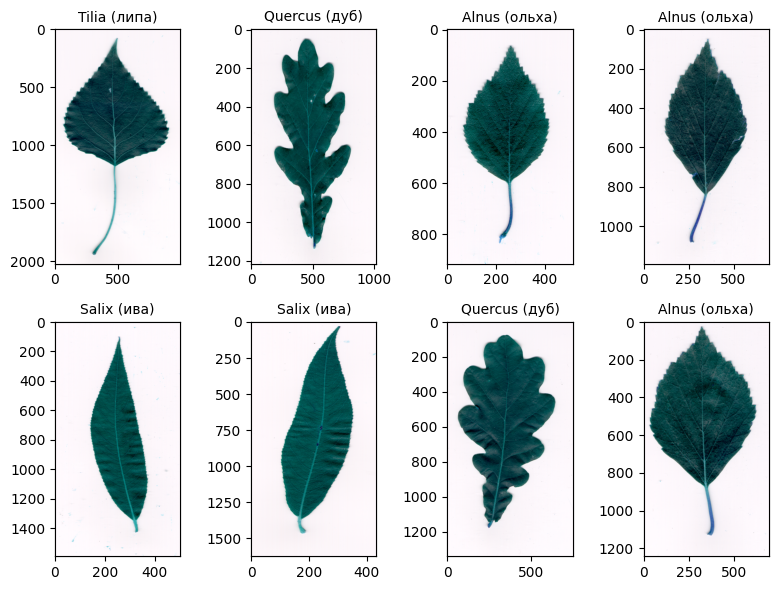

In [114]:
class_names = ['Quercus (дуб)', 'Alnus (ольха)', 'Salix (ива)', 'Tilia (липа)']
plot_images(train_images, train_labels, class_names)

Выполните преобразование изображений обучающей и тестовой выборок во временные ряды с помощью функции `image2ts()`.  

In [115]:
angle_step = 20

train_ts = np.array([Image2TimeSeries(angle_step).convert(img) for img in train_images])
test_ts  = np.array([Image2TimeSeries(angle_step).convert(img) for img in test_images])

print("train_ts:", train_ts.shape)
print("test_ts: ", test_ts.shape) 

train_ts: (60, 18)
test_ts:  (40, 18)


Для классификации временных рядов методом $k$ ближайших соседей вам необходимо использовать класс `TimeSeriesKNN` из модуля *classification.py*.
Реализуйте метод `fit()` в классе `TimeSeriesKNN`, который выполняет поиск для каждого элемента из тестовой выборки $k$ ближайших соседей и назначает им тот класс, который является часто встречающимся среди классов ближайших соседей. В качестве параметров в метод `fit()` передается тестовая выборка. Вычислите точность классификации по метрике accuracy с помощью функции `calculate_accurary()` из модуля *classification.py*.

In [116]:
n_neighbors = 6
metric = 'euclidean'
metric_params = {'normalize': True}

knn = TimeSeriesKNN(n_neighbors=n_neighbors, metric=metric, metric_params=metric_params)
knn.fit(train_ts, train_labels)
y_pred_euclidean = knn.predict(test_ts)

accuracy_euclidean = calculate_accuracy(test_labels, y_pred_euclidean)
print(f"Accuracy (euclidean): {accuracy_euclidean*100:.2f}%")

Accuracy (euclidean): 90.00%


In [117]:
metric = 'dtw'
metric_params = {'normalize': True}

knn = TimeSeriesKNN(n_neighbors=n_neighbors, metric=metric, metric_params=metric_params)
knn.fit(train_ts, train_labels)
y_pred_dtw = knn.predict(test_ts)

accuracy_dtw = calculate_accuracy(test_labels, y_pred_dtw)
print(f"Accuracy (dtw):       {accuracy_dtw*100:.2f}%")

Accuracy (dtw):       92.50%


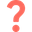
Проанализируйте результаты и сделайте выводы.

Точность предсказаний при использовании DTW получилась выше, чем при использовании обычного евклидова расстояния. Это связано с тем, что временные ряды из одной категории не будут полностью одинаковыми — между ними могут быть небольшие различия и смещения по времени.

В таком случае евклидово расстояние может учитывать эти смещения как сильное различие между рядами. DTW, в свою очередь, позволяет находить оптимальное соответствие между точками временных рядов и учитывать небольшие временные сдвиги. Поэтому в данном случае DTW показал более высокую точность предсказаний.